In [2]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd

from backtester.engine.costs import compute_trades

# Test 1: Simple single-stock position changes
positions = pd.Series([0, 0.2, 0.2, 0.2, 0])
trades = compute_trades(positions)
print("Single-stock trades:")
print(trades.tolist())


# Test 2: Multi-stock DataFrame
positions_multi = pd.DataFrame({
    "RELIANCE": [0.0, 0.2, 0.2, 0.0],
    "TCS":      [0.0, 0.2, 0.0, 0.0],
    "INFY":     [0.0, 0.0, 0.2, 0.0],
})
trades_multi = compute_trades(positions_multi)
print("\nMulti-stock trades:")
print(trades_multi.tolist())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Single-stock trades:
[nan, 0.2, 0.0, 0.0, 0.2]

Multi-stock trades:
[0.0, 0.4, 0.4, 0.4]


In [ ]:
"""Testing the momentum strategy returns with real data"""
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.strategies.strategies import momentum_signal

# Load universe
data = load_multiple_tickers(NIFTY_50, "2020-01-01", "2024-12-31")
prices = get_close_prices(data)
prices_clean = prices.dropna(axis=1, how="all")

# Generate momentum positions
positions = momentum_signal(prices_clean, lookback_months=12, top_n=5)

# Compute trade sizes each day
trades = compute_trades(positions)

print(f"Total trading periods: {len(trades.dropna())}")
print(f"Days with no trade:     {(trades == 0).sum()}")
print(f"Days with some trade:   {(trades > 0).sum()}")
print(f"\nAverage trade size on trading days: {trades[trades > 0].mean():.4f}")
print(f"Max single-day trade size: {trades.max():.4f}")

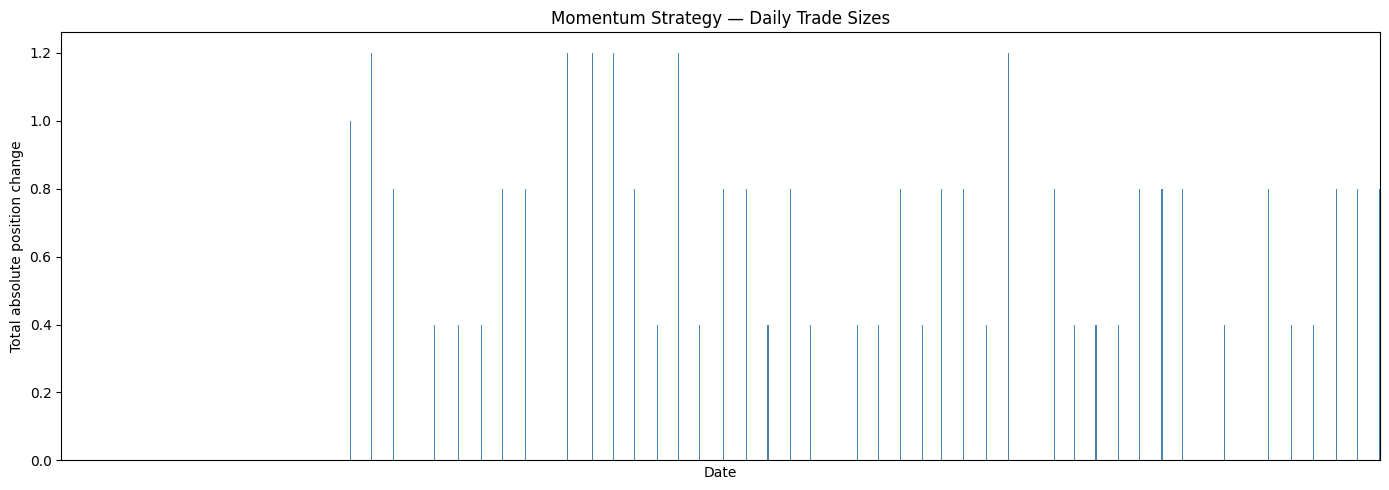

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
trades.dropna().plot(ax=ax, kind="bar", width=1.0, color="steelblue")
ax.set_title("Momentum Strategy — Daily Trade Sizes")
ax.set_ylabel("Total absolute position change")
ax.set_xticks([])  # Too many dates to show; just hide them
plt.tight_layout()
plt.show()

#### Applying costs to trades


In [3]:
from backtester.engine.costs import compute_costs, apply_costs_to_returns

# Set up a tiny test case
positions = pd.Series([0, 0.5, 0.5, 0.5, 0])
gross_returns = pd.Series([0.01, 0.01, 0.01, 0.01, 0.01])

# Compute costs
costs = compute_costs(positions)
print("Trades:        ", compute_trades(positions).tolist())
print("Costs:         ", costs.tolist())

# Apply costs to returns
net_returns = apply_costs_to_returns(gross_returns, positions)
print("\nGross returns: ", gross_returns.tolist())
print("Net returns:   ", net_returns.tolist())

Trades:         [nan, 0.5, 0.0, 0.0, 0.5]
Costs:          [nan, 0.00075, 0.0, 0.0, 0.00075]

Gross returns:  [0.01, 0.01, 0.01, 0.01, 0.01]
Net returns:    [nan, 0.00925, 0.01, 0.01, 0.00925]


### Applying Costs to Momentum strategy

In [4]:
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.strategies.strategies import momentum_signal
from backtester.metrics.metrics import daily_returns, performance_report

# Load universe
data = load_multiple_tickers(NIFTY_50, "2015-01-01", "2024-12-31")
prices = get_close_prices(data)
prices_clean = prices.dropna(axis=1, how="all")

# Run momentum strategy
positions = momentum_signal(prices_clean, lookback_months=12, top_n=5)
asset_returns = daily_returns(prices_clean)
shifted = positions.shift(1)
gross_strategy_returns = (shifted * asset_returns).sum(axis=1)

# Apply costs
net_strategy_returns = apply_costs_to_returns(gross_strategy_returns, positions)

# Compare reports
gross_report = performance_report(gross_strategy_returns.dropna())
net_report = performance_report(net_strategy_returns.dropna())

print(f"{'Metric':<25} {'Gross':>10} {'Net':>10}")
print("-" * 45)
for metric in gross_report:
    g = gross_report[metric]
    n = net_report[metric]
    print(f"{metric:<25} {g:>10.4f} {n:>10.4f}")

Loading RELIANCE.NS ...
Cache for RELIANCE.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading TCS.NS ...
Cache for TCS.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading INFY.NS ...
Cache for INFY.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache (2014-01-01 to 2025-12-30)
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache (2014-01-01 to 2025-12-30)
Loading ITC.NS ...
Loading ITC.NS from cache (2014-01-01 to 2025-12-30)
Loading LT.NS ...
Loading LT.NS from cache (2014-01-01 to 2025-12-30)
Loading KOTAKBANK.N

##### What if costs were different

In [5]:
print(f"{'Cost rate':>10} {'Return':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 42)

for cost_rate in [0.0000, 0.0005, 0.0015, 0.0030, 0.0050]:
    net_returns = apply_costs_to_returns(gross_strategy_returns, positions, cost_per_trade=cost_rate)
    report = performance_report(net_returns.dropna())
    print(f"{cost_rate:>10.4f} {report['annualized_return']:>10.4f} "
          f"{report['sharpe_ratio']:>10.4f} {report['max_drawdown']:>10.4f}")

 Cost rate     Return     Sharpe      MaxDD
------------------------------------------
    0.0000     0.1816     0.5371    -0.4586
    0.0005     0.1778     0.5204    -0.4619
    0.0015     0.1702     0.4870    -0.4686
    0.0030     0.1589     0.4373    -0.4784
    0.0050     0.1440     0.3714    -0.4913
